# Preliminaries

## The plan:
The plan of the project will be iterative, where we will merge the VAE notebook and the diffusion project, with appropriate modifications made for the new setting of latent diffusion. We will be working off the Wikipedia article: https://en.wikipedia.org/wiki/Latent_diffusion_model, which outlines some of the core aspects of the project. We will (preliminarily) use ~~the Caltech-256 dataset~~. We will use the Flowers101 dataset.

https://docs.pytorch.org/vision/2.0/generated/torchvision.datasets.LSUN.html

In [1]:
# Begin with some imports
import torch
import torch.optim as optim 
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset
import torch.nn.functional as F 
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


We will omit normalisation, as images are already in [0,1] range.

In [3]:
# Get training data, we want the full dataset. There is probably a better way to do this.
# Apply some transforms to get uniform images. 
flowers_train = datasets.Flowers102(
    root="data",
    split="train",
    download=True,
    transform=transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(256),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
)

flowers_test = datasets.Flowers102(
    root="data",
    split="test",
    download=True,
    transform=transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(256),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
)

flowers_val = datasets.Flowers102(
    root="data",
    split="val",
    download=True,
    transform=transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(256),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
)

training_data = torch.utils.data.ConcatDataset([flowers_test, flowers_train, flowers_val])
# 4 should be fine as we have 1 GPU, batch size decreased as the images are much bigger. 
train_loader = DataLoader(dataset=training_data, 
                          batch_size=32,
                          num_workers=4,
                          shuffle=True)

In [ ]:
# ''hacky'' approach to getting transforms to work on the subset
# from https://discuss.pytorch.org/t/torch-utils-data-dataset-random-split/32209/3
class MyDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            # very hacky, need to do this because of the images already being tensors. A wiser implementation would be to just keep the validation images around. 
            x = self.transform(transforms.ToPILImage()(x))
        return x, y
        
    def __len__(self):
        return len(self.subset)

# for checking what the model is actually doing, pick ~256 samples to augment 
validation_ind = np.random.choice(len(training_data), 256)

validation_data_sub = torch.utils.data.Subset(training_data, validation_ind)

t = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
])

validation_data = MyDataset(validation_data_sub, t)
validation_loader = DataLoader(dataset=training_data, 
                          batch_size=32,
                          num_workers=4,
                          shuffle=True)


52

55

99

235

24

12

128

174

107

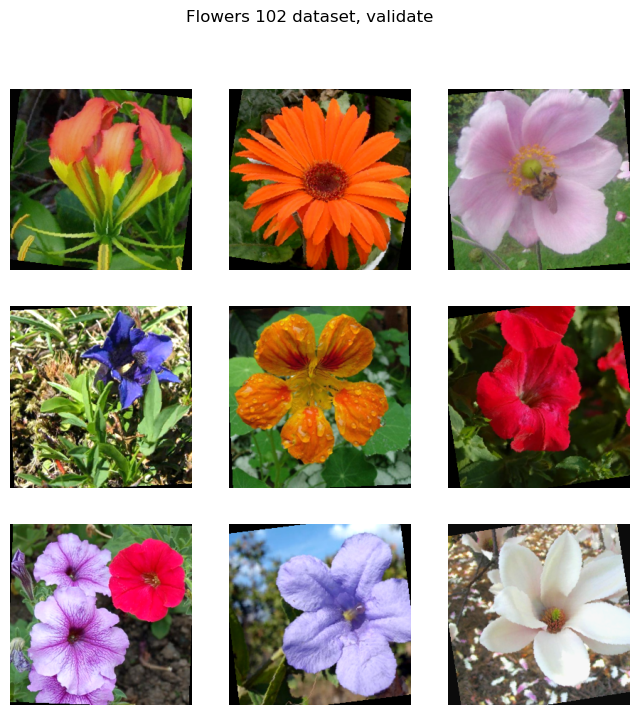

In [13]:
# Sanity check to visualise the validation dataset
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    #display(validation_data[0])
    sample_idx = torch.randint(len(validation_data), size=(1,)).item()
    display(sample_idx)
    
    # note structure: IMAGE, LABEL¨
    img, _ = validation_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.axis("off")
    plt.imshow(img.permute(1,2,0))
figure.suptitle("Flowers 102 dataset, validate")
plt.show()

# Dataset visualisation

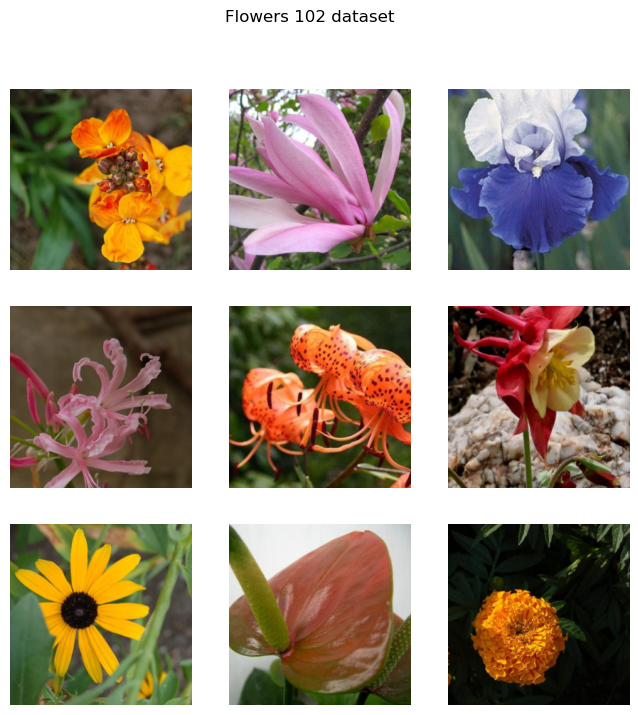

In [33]:
# just a quick plot to visualise the dataset
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    # note structure: IMAGE, LABEL¨
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.axis("off")
    plt.imshow(img.permute(1,2,0))
figure.suptitle("Flowers 102 dataset")
plt.show()

Notes on model architecture: initial version uses the same structure as in latent-diffusion-model.ipynb. 

https://stackoverflow.com/questions/58151507/why-pytorch-officially-use-mean-0-485-0-456-0-406-and-std-0-229-0-224-0-2

In [7]:
# utility functions

# loss function for the VAE, same as in the VAE notebook. 
def loss_function_VAE(recon_x, x, mu, logvar, beta=1.0):
    recon_loss = F.binary_cross_entropy_with_logits(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    #return recon_loss + beta * kl_loss, recon_loss, kl_loss
    return recon_loss + beta*kl_loss

# linear ramp for KL to try to make it not dissapear
def get_kl_weight(epoch, warmup_epochs=200, max_beta=0.01):
    if epoch < warmup_epochs:
        return 0.0  # reconstruction only, let decoder learn first
    else:
        # linear ramp from 0 to max_beta over next 300 epochs
        ramp = (epoch - warmup_epochs) / 300
        return min(max_beta, ramp * max_beta)
    
# cyclical alternative, roughly like (although its used for NLP contexts might be feasible here)
# https://aclanthology.org/N19-1021.pdf
def get_kl_weight_cyclical(epoch, cycle_length=200, max_beta=0.01, n_cycles=4):
    cycle = epoch/cycle_length
    # we are over 4*200=800 epochs, return max
    if cycle >= n_cycles:
        return max_beta
    
    # location within cycle
    cycle_pos = (epoch % cycle_length) / cycle_length

    if cycle_pos < 0.5:
        return(cycle_pos/0.5)*max_beta
    else:
        return max_beta
    
# function to check how the latent space is doing
# TODO

# The plan

First we have to train the VAE. We need to alter the structure from the previous notebooks as we will be using diffusion on the latent space, so we will get rid of the overarching class. Then once training is done, we will need to save the model weights. Note that we also need to possibly make further alterations to the Enoder/Decoder structure. We annotate changes where possible. 

We started with beta =0.01, and we try with 0.5. 

In [11]:
# Define model, encoder decoder seperately

class Encoder(nn.Module):
    # allows for hidden layer etc. experimentation
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        # we know that the images are 256x256, so we do not need any special handling.
        hidden_dim= 128*(256//8)*(256//8)
        self.f_mu = nn.Linear(hidden_dim,latent_dim)
        self.f_logvar = nn.Linear(hidden_dim,latent_dim)

        self.encoder_stack = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Flatten()
        )

    # needed to make the gradients flow. Compared to the other notebook, we define this here. This is so that we can train the diffusion model in the latent space (this is my understanding of how latent diffusion works)
    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5*logvar) # standard deviation
        eps = torch.randn_like(std) # random noise
        return mu+eps*std   # sample

    def forward(self,x):
        x = self.encoder_stack(x)
        mu = self.f_mu(x)
        f_logvar = self.f_logvar(x)
        z = self.reparameterise(mu, f_logvar)
        # returns z here - we change variables so that it is clearer what we are doing. 
        return z, mu, f_logvar

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        hidden_dim = 128*(256//8)*(256//8)
        #display(hidden_dim)
        pre_flatten_shape = (128, 32, 32)
        # fully connected layer
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        # define a helper to reshape to allow for tensor operations
        self.reshape = lambda x: x.view(-1, *pre_flatten_shape)

        self.decoder_stack= nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3,stride=2,padding=1, output_padding= 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3,stride=2,padding=1,output_padding= 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=3,stride=2,padding=1,output_padding= 1)
            #nn.ReLU(),
            #nn.Sigmoid()
        )        

    def forward(self,x): 
        x = self.fc1(x)
        x = self.reshape(x)
        
        x = self.decoder_stack(x)
        
        return x


In [8]:
# Modified model. Note that unlike for the first version, the realisation that dealing with an unified architecture has been made. There should be no problems with this, while also simplifying the training process.

class Encoder(nn.Module):
    # allows for hidden layer etc. experimentation
    def __init__(self):
        super(Encoder, self).__init__()
        # we know that the images are 256x256, so we do not need any special handling.
        self.f_mu =     nn.Conv2d(128, 4, kernel_size=1)  # (N, 4, 32, 32)
        self.f_logvar = nn.Conv2d(128, 4, kernel_size=1)  # (N, 4, 32, 32)

        self.encoder_stack = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3,stride=2,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3,stride=2,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3,stride=2,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            #nn.Flatten()
        )
    def forward(self,x):
        x = self.encoder_stack(x)
        mu = self.f_mu(x)
        f_logvar = self.f_logvar(x)
        # return mu, f_logvar to be reparameterised.
        return mu, f_logvar

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        #display(hidden_dim)
        # fully connected layer
        # define a helper to reshape to allow for tensor operations

        self.decoder_stack= nn.Sequential(
            nn.ConvTranspose2d(4, 128, kernel_size=3, stride=2, padding=1, output_padding=1),  # 32 -> 64
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=3,stride=2,padding=1, output_padding= 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3,stride=2,padding=1,output_padding= 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=1),
            #nn.Sigmoid()
        )        

    def forward(self,x): 
        x = self.decoder_stack(x)
        return x
    

class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    """Simple reparameteratisation function to allow for gradients to flow through the model.
        Inputs: mu, logvar
        Note the clamping, we use this to make sure the variance does not blow up, basically."""
    def reparameterise(self, mu, logvar):
        # to avoid the loss exploding
        logvar = torch.clamp(logvar, -4, 4)
        std = torch.exp(0.5*logvar) # standard deviation
        eps = torch.randn_like(std) # random noise
        return mu+eps*std   # sample
    

    
    def forward(self, x):
        # simple loop
        mu, logvar = self.encoder(x)
        z = self.reparameterise(mu, logvar)
        reconstructed = self.decoder(z)
        return reconstructed, mu, logvar


Idea for additional discussion: comparative training of linear scheduler vs cyclical. There is probably a writeup there, but this is not the main aim of the model. 

In [9]:
epochs = 1000
learning_rate = 1e-3

model = VAE().to(device)

optimizer = torch.optim.AdamW(model.parameters(),lr=learning_rate)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=100,   
    T_mult=2,   
    eta_min=1e-6
)

In [10]:
# Save checkpoint every N epochs
# some boilerplate code for saving and loading checpoints
def save_checkpoint(model, optimizer, scheduler, epoch, loss, path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'loss': loss,
    }, path)

# Load checkpoint
def load_checkpoint(model, optimizer, scheduler, path):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    return checkpoint['epoch'], checkpoint['loss']


In [ ]:
# CODE to train from zero
train_losses = []

model.train()


# initialise here
best_loss = torch.inf

for epoch in range(epochs):
    #kl_weight = get_kl_weight(epoch)
    kl_weight = get_kl_weight_cyclical(epoch)
    total_loss = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.to(device)
        optimizer.zero_grad()

        recon_x, mu, logvar = model(x)

        loss = loss_function_VAE(recon_x, x, mu, logvar, beta=kl_weight)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss/len(train_loader.dataset)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    # In training loop
    if epoch % 50 == 0:
        save_checkpoint(model, optimizer, scheduler, epoch, loss, f'weights/VAE_checkpoint_epoch_{epoch}.pt')

    # Always save best model separately
    if avg_loss < best_loss:
        best_loss = avg_loss
        save_checkpoint(model, optimizer, scheduler, epoch, loss, f'weights/VAE_best_model.pt')
    
    # Always save the last model:
    if epoch < epochs-1:
        save_checkpoint(model,optimizer, scheduler, epoch,loss, f'weigths/VAE_last_model.pt')


plt.plot(train_losses)
plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()




Epoch 1, Loss: 99297.1608
Epoch 11, Loss: 96013.9692
Epoch 21, Loss: 95841.0070
Epoch 31, Loss: 95723.0227
Epoch 41, Loss: 95708.7026
Epoch 51, Loss: 95675.8375
Epoch 61, Loss: 95615.2394
Epoch 71, Loss: 95608.4861
Epoch 81, Loss: 95669.8442
Epoch 91, Loss: 95616.1025
Epoch 101, Loss: 95571.3763
Epoch 111, Loss: 95581.4131
Epoch 121, Loss: 95588.2938
Epoch 131, Loss: 95590.9833
Epoch 141, Loss: 95579.2591
Epoch 151, Loss: 95546.1606
Epoch 161, Loss: 95514.2808
Epoch 171, Loss: 95584.9702
Epoch 181, Loss: 95570.5122
Epoch 191, Loss: 95538.0609
Epoch 201, Loss: 95355.2786
Epoch 211, Loss: 95357.6333
Epoch 221, Loss: 95373.9461
Epoch 231, Loss: 95398.3137
Epoch 241, Loss: 95367.1887
Epoch 251, Loss: 95413.3427
Epoch 261, Loss: 95421.2676
Epoch 271, Loss: 95469.3898
Epoch 281, Loss: 95448.8316
Epoch 291, Loss: 95437.4682
Epoch 301, Loss: 95476.7280
Epoch 311, Loss: 95516.7179
Epoch 321, Loss: 95436.5527
Epoch 331, Loss: 95441.7199
Epoch 341, Loss: 95422.6042
Epoch 351, Loss: 95458.2691
Epo

In [12]:
# utility cell to demonstrate loading model
checkpoint, loss = load_checkpoint(model,optimizer,scheduler,"weights/VAE_checkpoint_epoch_550.pt")
# note: outputs loss of batch/should be fixed. 
display(f"Loaded checkpoint {checkpoint} with loss {loss}")

'Loaded checkpoint 550 with loss 2977459.25'

The training loop should be improved slightly. One approach is to sample images once in a while to see how the model is progressing. TODO: exactly this.

'Loaded checkpoint 550 with loss 2615994.75. Resuming training'

Epoch 551, Loss: 95344.5730
Epoch 561, Loss: 95409.0038
Epoch 571, Loss: 95376.8631
Epoch 581, Loss: 95374.9471
Epoch 591, Loss: 95405.2558
Epoch 601, Loss: 95216.0777
Epoch 611, Loss: 95250.7182
Epoch 621, Loss: 95252.8505
Epoch 631, Loss: 95265.3671
Epoch 641, Loss: 95284.2319
Epoch 651, Loss: 95314.6124
Epoch 661, Loss: 95292.8131
Epoch 671, Loss: 95342.6321
Epoch 681, Loss: 95336.9555
Epoch 691, Loss: 95360.9581
Epoch 701, Loss: 95343.5347
Epoch 711, Loss: 95408.0938
Epoch 721, Loss: 95370.5030
Epoch 731, Loss: 95371.6100
Epoch 741, Loss: 95388.9111
Epoch 751, Loss: 95382.4682
Epoch 761, Loss: 95334.2820
Epoch 771, Loss: 95334.2293
Epoch 781, Loss: 95339.4077
Epoch 791, Loss: 95373.3839
Epoch 801, Loss: 95385.3333
Epoch 811, Loss: 95372.4187
Epoch 821, Loss: 95328.9193
Epoch 831, Loss: 95357.4824
Epoch 841, Loss: 95328.9592
Epoch 851, Loss: 95349.0420
Epoch 861, Loss: 95356.7894
Epoch 871, Loss: 95364.5535
Epoch 881, Loss: 95319.4368
Epoch 891, Loss: 95328.2601
Epoch 901, Loss: 953

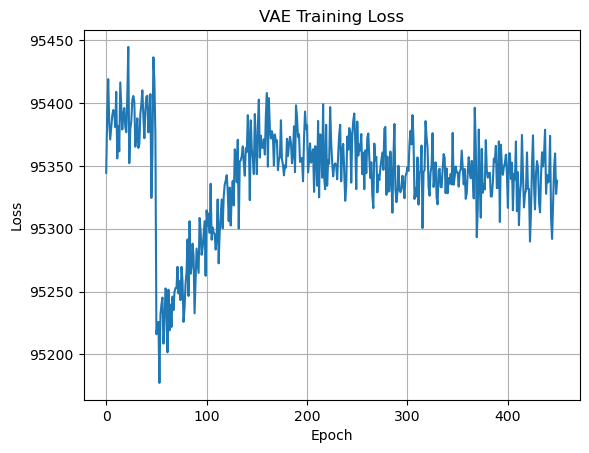

In [15]:
last_epoch = 550
# change
max_epoch = 1000

checkpoint, loss = load_checkpoint(model,optimizer,scheduler,"weights/VAE_checkpoint_epoch_550.pt")

display(f"Loaded checkpoint {checkpoint} with loss {loss}. Resuming training")

train_losses = []
model.train()

best_loss = torch.inf

for epoch in range(last_epoch,max_epoch):
    kl_weight = get_kl_weight_cyclical(epoch)
    total_loss = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.to(device)
        optimizer.zero_grad()

        recon_x, mu, logvar = model(x)

        loss = loss_function_VAE(recon_x, x, mu, logvar, beta=kl_weight)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    avg_loss = total_loss/len(train_loader.dataset)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    # In training loop
    if epoch % 50 == 0:
        save_checkpoint(model, optimizer, scheduler, epoch, loss, f'weights/VAE_checkpoint_epoch_{epoch}.pt')

    # Always save best model separately
    if avg_loss < best_loss:
        best_loss = avg_loss
        save_checkpoint(model, optimizer, scheduler, epoch, loss, f'weights/VAE_best_model.pt')
    
    # Always save the last model:
    if epoch == max_epoch-1:
        save_checkpoint(model,optimizer, scheduler, epoch,loss, f'weights/VAE_last_model.pt')

plt.plot(train_losses)
plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


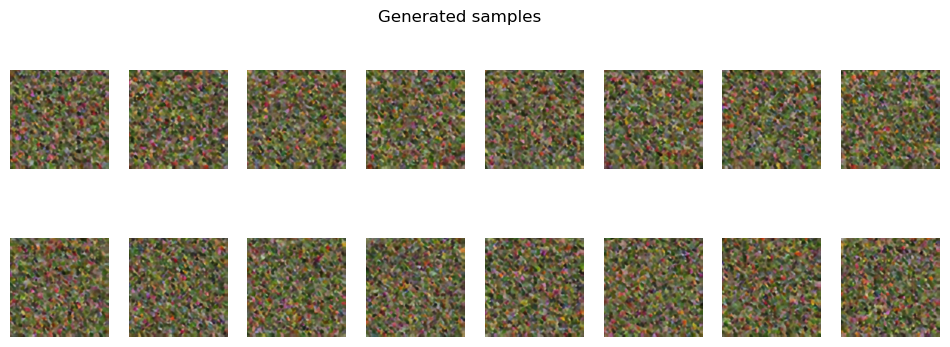

In [16]:


model.eval()
with torch.no_grad():
    z = torch.randn((16,4,32,32)).to(device)
    
    generated = torch.sigmoid(model.decoder(z)).cpu()

# plot generated samples
fig, axes = plt.subplots(2,8,figsize=(12,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].permute(1,2,0))
    ax.axis('off')

plt.suptitle("Generated samples")
plt.show()

mu mean: 0.139, std: 1.915
logvar mean: -4.025, std: 0.065


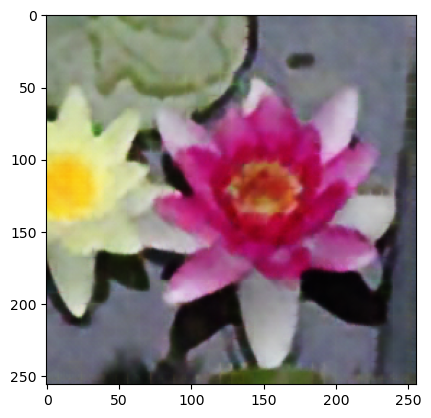

In [25]:
# Image reconstruction
#for i in range(1, cols * rows + 1):
#    sample_idx = torch.randint(len(training_data), size=(1,)).item()
#    # note structure: IMAGE, LABEL¨
#    img, label = training_data[sample_idx]
#    img = img.to(device)
#    generated = torch.sigmoid(decoder(encoder(img))).cpu()
    

#    figure.add_subplot(rows, cols, i)
#    plt.axis("off")
#    plt.imshow(generated.permute(1,2,0))
#figure.suptitle("Flowers 102 dataset")
#plt.show()

with torch.no_grad():
    real_batch, _ = next(iter(train_loader))
    real_batch = real_batch.to(device)
    recon, mu, logvar = model(real_batch)
    recon = torch.sigmoid(recon[0])
    recon = recon.cpu()

    plt.imshow(recon.permute(1,2,0))
    print(f"mu mean: {mu.mean():.3f}, std: {mu.std():.3f}")
    print(f"logvar mean: {logvar.mean():.3f}, std: {logvar.std():.3f}")